# Template Lab 1: Hooke’s Law Report

**Course:** University Physics I Laboratory  
**Name(s):** [Enter your name(s)]  
**Date:** [Enter date]  

---

## Abstract
*Write 100–150 words: purpose, method, key result, conclusion*

---

## Introduction
- State Hooke’s Law: $ F = kx $  
- Explain physical meaning of $F$, $x$, and $k$.  
- Why linear regression is appropriate.  
- Expectation: intercept $ \approx 0 $.  

---

## Methods
Briefly describe the workflow you will use (with code cells inserted where applicable):
1. Import CSV files (provide code as it is not part of the results).
2. Subset data by spring (`A`, `B`) (provide code as it is not part of the results).
3. Perform a linear fit of `F = kx + b` and estimate uncertainties (code will be shown in *Results*).
4. Produce publication-quality plots (labels, units, captions) (code will be shown in *Results*).
5. Compare measured `k` to manufacturer spec with tolerance (*Discussion* section).

### Data Import and Data Subset
*Your description*

In [9]:
# DIY Code Cell: Data import and subset - An example solution is provided below if you need it

In [10]:
import pandas as pd

# Load data
data = pd.read_csv("hookes_law_synthetic_lab.csv")

A = data.query("spring == 'A'").copy()
B = data.query("spring == 'B'").copy()

---

## Results
Analyze **each spring** separately: make a scatter plot of `F` vs `x`, overlay the best-fit line, and show a residual plot.
Also report `k ± u_k` and `b ± u_b`.

### Spring A: Fit & Plots

*Make short comments followed by code**

In [ ]:
# DIY Code Cell: Linear Fit - An example solution is provided below if you need it

In [13]:
import numpy as np

# --- Linear fit for Spring A: F = k*x + b ---
x = A["extension_m"].values
y = A["force_N"].values

# Unweighted linear regression with covariance for uncertainties
p, cov = np.polyfit(x, y, deg=1, cov=True)
k_A, b_A = p[0], p[1]
u_kA, u_bA = np.sqrt(np.diag(cov))

print(f"k_A = {k_A:.3f} ± {u_kA:.3f} N/m")
print(f"b_A = {b_A:.3f} ± {u_bA:.3f} N")

k_A = 11.372 ± 0.461 N/m
b_A = 0.059 ± 0.063 N
[[ 0.21244545 -0.026381  ]
 [-0.026381    0.0039267 ]]


*Make short comments followed by code*

In [18]:
# DIY Code Cell: Plot - An example solution is provided below if you need it

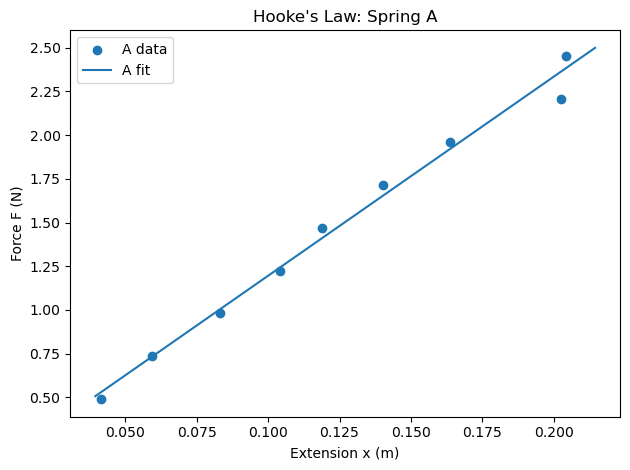

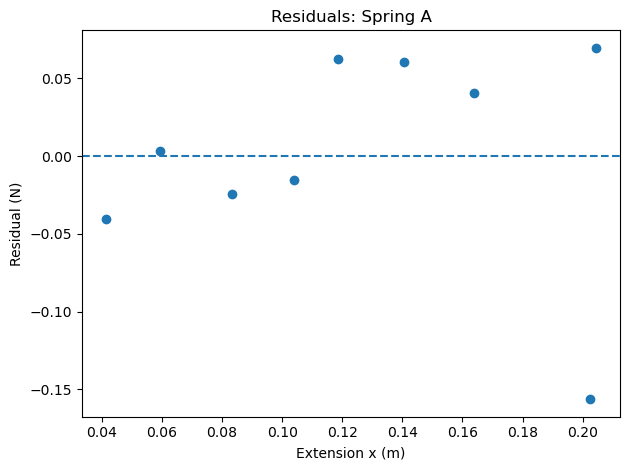

In [17]:
import matplotlib.pyplot as plt

# Plot data + fit
x_line = np.linspace(x.min()*0.95, x.max()*1.05, 200)
y_line = k_A * x_line + b_A

plt.figure()
plt.scatter(x, y, label="A data")
plt.plot(x_line, y_line, label="A fit")
plt.xlabel("Extension x (m)")
plt.ylabel("Force F (N)")
plt.title("Hooke's Law: Spring A")
plt.legend()
plt.tight_layout()
plt.show()

# Residuals
y_fit = k_A * x + b_A
res = y - y_fit
plt.figure()
plt.axhline(0, linestyle="--")
plt.scatter(x, res)
plt.xlabel("Extension x (m)")
plt.ylabel("Residual (N)")
plt.title("Residuals: Spring A")
plt.tight_layout()
plt.show()

### Spring B: Fit & Plots

*Repeat the process for spring B*

In [ ]:
# DIY Code Cell: Linear Fit - An example solution is provided below if you need it

In [18]:
# DIY Code Cell: Plot - An example solution is provided below if you need it

---

### Summary Table
Create a small Markdown table summarizing your fitted parameters:

| Spring | \(k\) (N/m) | \(u_k\) (N/m) | \(b\) (N) | \(u_b\) (N) |
|---|---:|---:|---:|---:|
| A |  |  |  |  |
| B |  |  |  |  |


---

## Comparison to Manufacturer Specs

*Read in manufacturers spec file and print value for comparison*

In [19]:
# DIY Code Cell: Compare to manucturer

In [22]:
specs = pd.read_csv("hookes_law_specs.csv")

def compare_to_spec(spring_label, k_meas, u_k):
    k_spec = float(specs.loc[specs['spring']==spring_label,'manufacturer_k_N_per_m'].iloc[0])
    tol = float(specs.loc[specs['spring']==spring_label,'tolerance_percent'].iloc[0])
    pct_diff = 100.0 * abs(k_meas - k_spec) / k_spec
    within = pct_diff <= tol
    print(f"Spring {spring_label}: Spec k = {k_spec:.2f} N/m (±{tol:.1f}%)")
    print(f"  Measured k = {k_meas:.2f} ± {u_k:.2f} N/m")
    print(f"  Percent difference = {pct_diff:.2f}%  ->  Within tolerance? {'Yes' if within else 'No'}")
    
compare_to_spec('A', k_A, u_kA)
#compare_to_spec('B', k_B, u_kB)

Spring A: Spec k = 12.50 N/m (±5.0%)
  Measured k = 11.37 ± 0.46 N/m
  Percent difference = 9.02%  ->  Within tolerance? No


---

## Discussion
- Identify possible outliers (justify keep/remove).  
- Dominant uncertainty sources (instrument resolution, alignment, mass labels).  
- Residual trends (evidence of nonlinearity?).  
- Limitations and improvements for a future experiment.


---

## Conclusion
*3–5 sentences summarizing your final numbers and whether they are consistent with the specs.*


---

## References
*List any sources used (textbook, notes). Use a consistent citation style.*


---

# To Save as HTML

### Exporting a Colab Notebook to HTML (Step-by-Step)

To create an HTML (webpage) version of a Colab notebook, follow these steps carefully.

1. **Download the notebook file**  
   In Colab, go to **File → Download → Download `.ipynb`** to save the notebook to your computer.

2. **Upload the notebook to Google Drive**

   * Open **drive.google.com** in your browser.
   * Create a folder named`Physics-I-Lab`.
   * Click **New → File upload**, and upload the `lab1_template.ipynb` file you just downloaded into your newly created directory.
   * Rename the file `lab1_template.ipynb` --> `lab1.ipynb`.

3. **Open the File in Colab**

   Click on the three dots on the top right corner of your file. Choose "Open with" then "Google Colaboratory".

4. **Mount Google Drive in Colab**  
   At the bottom of your file, add a code cell and run the following command:

    
   `from google.colab import drive`  
   `drive.mount('/content/drive')`

   
   Follow the authorization instructions when prompted.

5. **Convert the notebook to HTML**  
   In a new code cell, replace the folder names and filename below so they match your Google Drive path. For example:
   
   `!jupyter nbconvert --to html --no-input --embed-images "/content/drive/MyDrive/Physics-I-Lab/lab1.ipynb"`

    
   This will create an HTML file in the same Google Drive folder.

6. **Download the HTML file**  
   Right-click the file `lab1.html` and select **Download**.

You now have a static HTML version of your notebook that can be opened in any web browser and you can submit to canvas.

---